# Nama: Valdhy Maulana Alzikri
# NIM:  4222301070
# Kelas: Robotika C Pagi

In [53]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Load Our Dataset

In [54]:
df = pd.read_csv('winequality-red.csv')

## EDA

Text(0.5, 1.0, 'Sebaran Nilai alcohol vs quality')

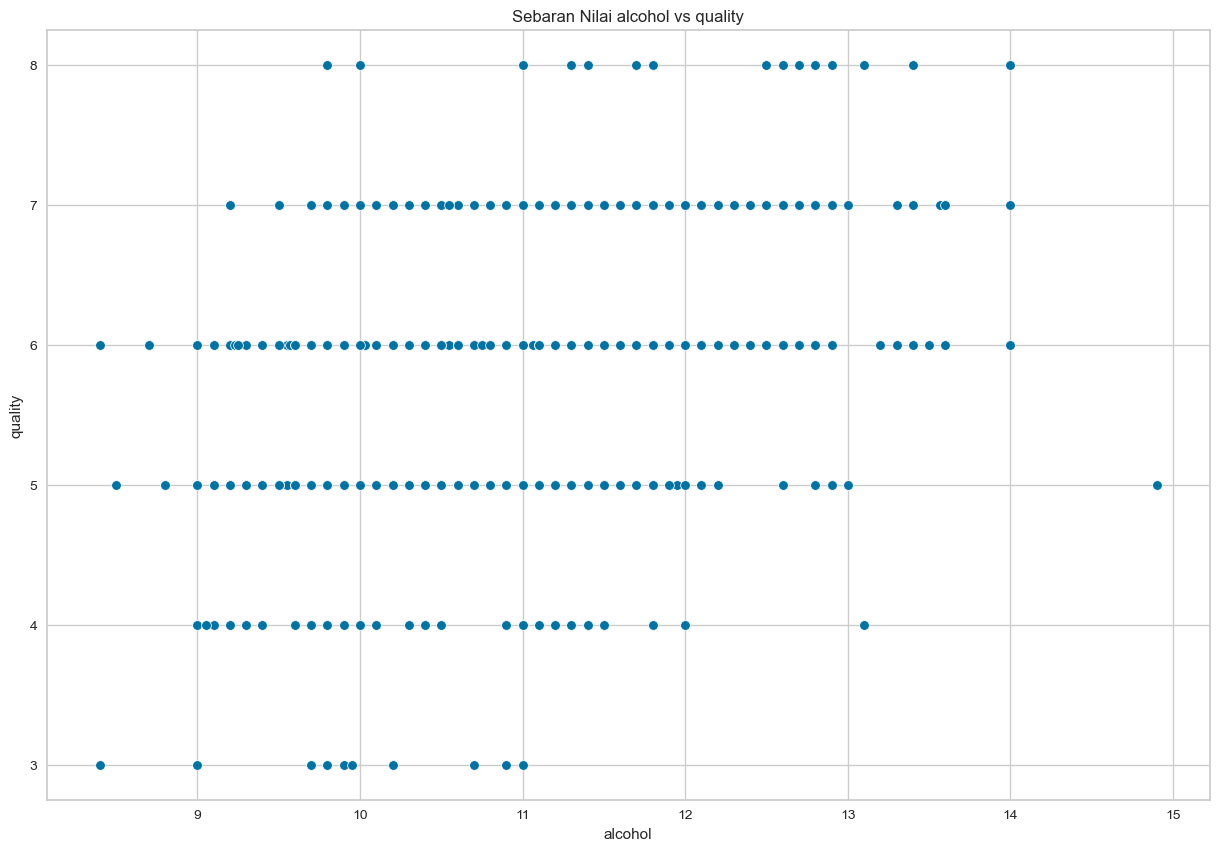

In [55]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='quality')
plt.title('Sebaran Nilai alcohol vs quality')

In [56]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


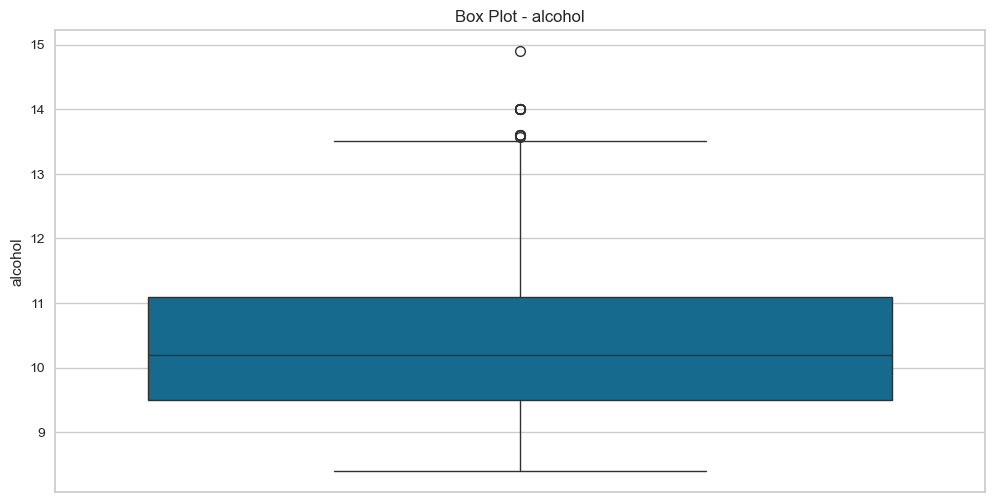

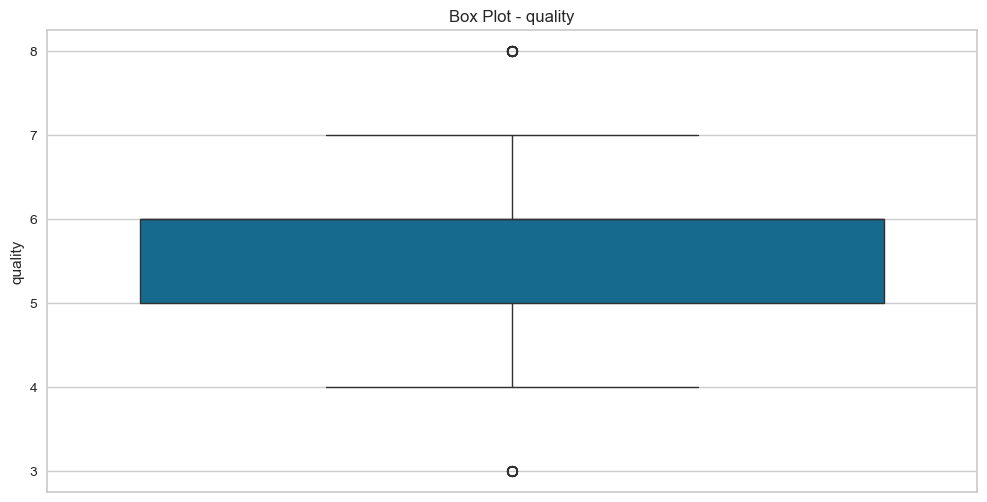

In [57]:
# Looping untuk kolom 'alcohol' dan 'quality'
columns = ['alcohol', 'quality']

for col in columns:
    # Box plot
    plt.figure(figsize=(12, 6))
    sns.boxplot(y=col, data=df)
    plt.title(f'Box Plot - {col}')
    plt.ylabel(col)
    plt.show()

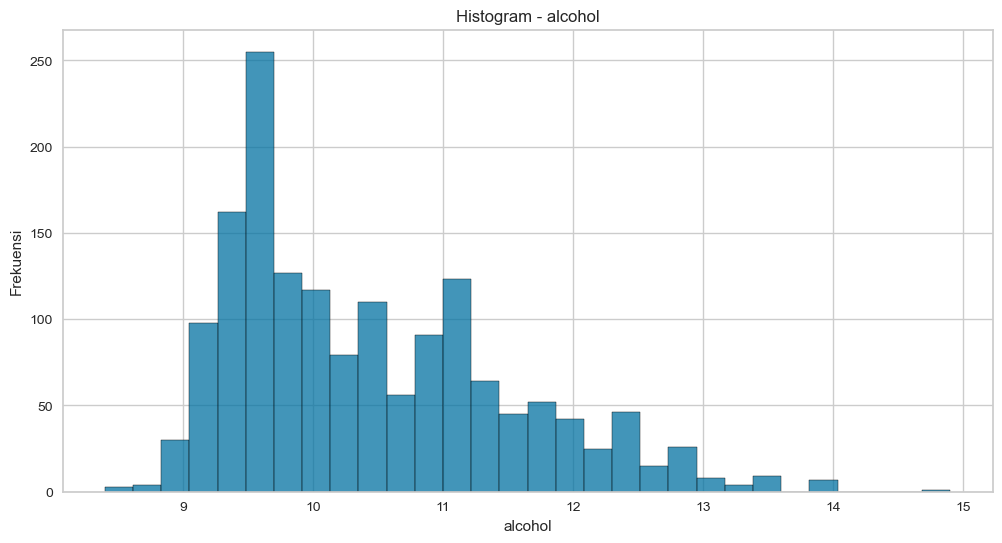

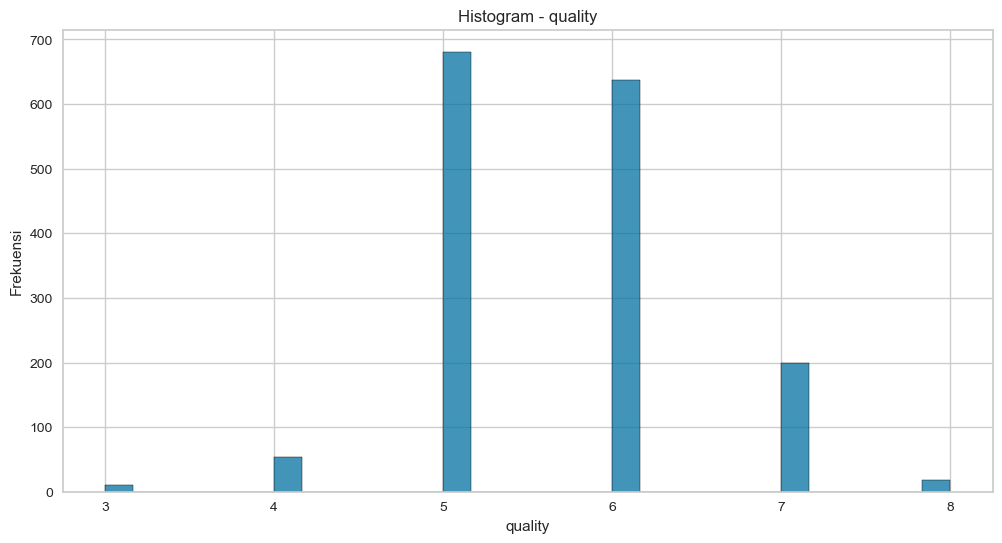

In [58]:
for col in columns:
    # Histogram
    plt.figure(figsize=(12, 6))
    sns.histplot(df[col], bins=30, kde=False)
    plt.title(f'Histogram - {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

## Feature Engineering
* Unsupervised tidak perlu dilakukan splitting
1. Drop Duplikat
2. Outlier Handling (opsional)-> pada step ini tidak perlu, karena berat dan tinggi masih wajar untuk nilai seperti itu
3. Feature Scalling

In [59]:
# Drop Duplicates

print(f"Dataframe dimension before duplication drop {df.shape[0]}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataframe dimension after duplication drop {df.shape[0]}")

Dataframe dimension before duplication drop 1599
Dataframe dimension after duplication drop 1359


dari hasil running program diatas, tidak ada data yg duplikat

In [60]:
fitur_columns = df.columns[:-1].tolist()  # Semua kolom kecuali quality
X = df[fitur_columns].values
y = df['quality'].values  # quality sebagai referensi label

In [61]:
# Feature Scalling
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)
df_scalling = pd.DataFrame(data = X_std, columns = fitur_columns )
df_scalling.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1.359000e+03,1.359000e+03,1.359000e+03,1.359000e+03,1.359000e+03,1.359000e+03,1.359000e+03,1.359000e+03,1.359000e+03,1.359000e+03,1.359000e+03
mean,-6.274108e-16,1.463959e-16,2.091369e-17,-1.202537e-16,1.882232e-16,-8.365477e-17,4.182739e-17,5.286982e-14,-1.202537e-15,-5.542129e-16,1.254822e-16
std,1.000368e+00,1.000368e+00,1.000368e+00,1.000368e+00,1.000368e+00,1.000368e+00,1.000368e+00,1.000368e+00,1.000368e+00,1.000368e+00,1.000368e+00
min,-2.137008e+00,-2.238023e+00,-1.393258e+00,-1.200903e+00,-1.542254e+00,-1.426094e+00,-1.222457e+00,-3.553604e+00,-3.676535e+00,-1.926712e+00,-1.878873e+00
25%,-6.972071e-01,-7.623226e-01,-9.328165e-01,-4.611571e-01,-3.671819e-01,-8.515696e-01,-7.433672e-01,-5.935822e-01,-6.438707e-01,-6.371766e-01,-8.619244e-01
50%,-2.364707e-01,-5.180013e-02,-6.309377e-02,-2.392334e-01,-1.848432e-01,-1.812915e-01,-2.642772e-01,-4.789431e-03,1.376908e-03,-2.268699e-01,-2.147753e-01
75%,5.122260e-01,6.040667e-01,8.066290e-01,5.666484e-02,5.827504e-02,4.889867e-01,4.843008e-01,5.947087e-01,5.820998e-01,4.178978e-01,6.172735e-01
max,4.370894e+00,5.741690e+00,3.722758e+00,9.599383e+00,1.059340e+01,5.372442e+00,7.251446e+00,3.736721e+00,4.518110e+00,7.862034e+00,4.130369e+00


In [62]:
X_std

array([[-0.52443096,  0.93200015, -1.39325797, ...,  1.29187216,
        -0.57856134, -0.95437429],
       [-0.29406274,  1.91580043, -1.39325797, ..., -0.70839548,
         0.12482157, -0.5845748 ],
       [-0.29406274,  1.25993358, -1.18861732, ..., -0.32124691,
        -0.05102416, -0.5845748 ],
       ...,
       [-1.38831178,  0.11216658, -0.88165635, ...,  1.35639693,
         0.59374351,  0.7097234 ],
       [-1.38831178,  0.63139451, -0.77933603, ...,  1.67902074,
         0.3006673 , -0.21477532],
       [-1.33071973, -1.19956712,  1.01126962, ...,  0.51757501,
         0.00759108,  0.52482366]])

In [63]:
df_scalling

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.524431,0.932000,-1.393258,-0.461157,-0.245623,-0.468554,-0.384050,0.584003,1.291872,-0.578561,-0.954374
1,-0.294063,1.915800,-1.393258,0.056665,0.200094,0.872003,0.604073,0.048737,-0.708395,0.124822,-0.584575
2,-0.294063,1.259934,-1.188617,-0.165259,0.078535,-0.085537,0.214813,0.155790,-0.321247,-0.051024,-0.584575
3,1.664067,-1.363534,1.471711,-0.461157,-0.265883,0.105971,0.394471,0.691057,-0.966495,-0.461331,-0.584575
4,-0.524431,0.713378,-1.393258,-0.535132,-0.265883,-0.277045,-0.204391,0.584003,1.291872,-0.578561,-0.954374
...,...,...,...,...,...,...,...,...,...,...,...
1354,-0.869983,0.494756,-0.983977,-0.461157,-0.407702,1.159265,-0.264277,-0.106490,0.711149,0.945435,-0.861924
1355,-1.215536,0.385444,-0.983977,-0.387183,0.038015,1.542281,-0.084619,-0.968269,0.904724,-0.461331,0.062574
1356,-1.388312,0.112167,-0.881656,-0.239233,-0.529261,2.212559,0.124983,-0.850510,1.356397,0.593744,0.709723
1357,-1.388312,0.631395,-0.779336,-0.387183,-0.265883,1.542281,-0.084619,-0.663167,1.679021,0.300667,-0.214775


## TO DO!
- Lengkapi Code dibawah ini, untuk mengecek distribusi sebelum dan setelah dilakukan feature scalling menggunakan standar scaller

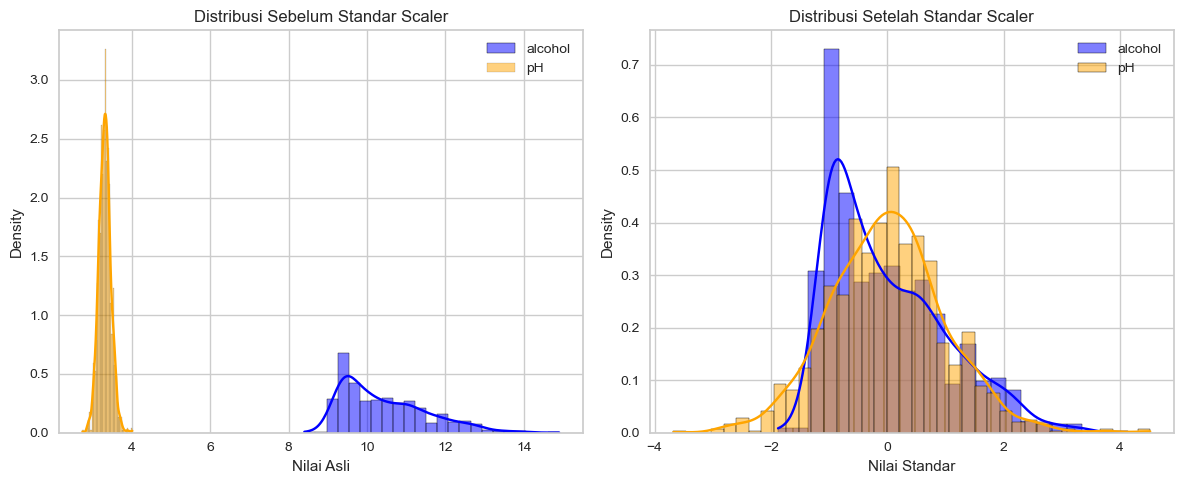

In [64]:
#cek grafik sebelum dan setelah scalling
# kita lihat distribusi dari variabel sebelum standar scaller dan setelah standar scaller

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Plot distribusi sebelum Standar Scaler (menggunakan 2 fitur penting: alcohol dan pH)
sns.histplot(df['alcohol'], kde=True, color='blue', ax=ax1, label='alcohol', stat='density', alpha=0.5)
sns.histplot(df['pH'], kde=True, color='orange', ax=ax1, label='pH', stat='density', alpha=0.5)
ax1.set_title('Distribusi Sebelum Standar Scaler')
ax1.set_xlabel('Nilai Asli')
ax1.set_ylabel('Density')
ax1.legend()

# Plot distribusi setelah Standar Scaler (setelah scaling, nilai berpusat di 0)
sns.histplot(df_scalling['alcohol'], kde=True, color='blue', ax=ax2, label='alcohol', stat='density', alpha=0.5)
sns.histplot(df_scalling['pH'], kde=True, color='orange', ax=ax2, label='pH', stat='density', alpha=0.5)
ax2.set_title('Distribusi Setelah Standar Scaler')
ax2.set_xlabel('Nilai Standar')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
1. Setelah Standar Scaler, distribusi fitur `alcohol` dan `quality` menjadi terpusat di sekitar nol dengan sebaran yang lebih seragam, menunjukkan bahwa skala antar fitur sudah distandarisasi.
2. Sebelum scaling, kedua fitur memiliki rentang dan variansi berbeda sehingga dapat mempengaruhi model clustering; setelah scaling, pengaruh fitur menjadi seimbang dan model dapat memproses keduanya secara adil.
3. Standardisasi ini penting agar semua 11 fitur dalam dataset wine quality memiliki kontribusi yang seimbang dalam proses clustering KMeans.

## K-means Clustering
Pada pembahasan kali ini akan diuji 2 metode pemilihan nilai cluster (K) yang terbaik, mendekati distribusi label quality yang ada.
1. Metode Elbow
2. Via-Score plot

### Metode Elbow

Text(0, 0.5, 'Intertia / WSS')

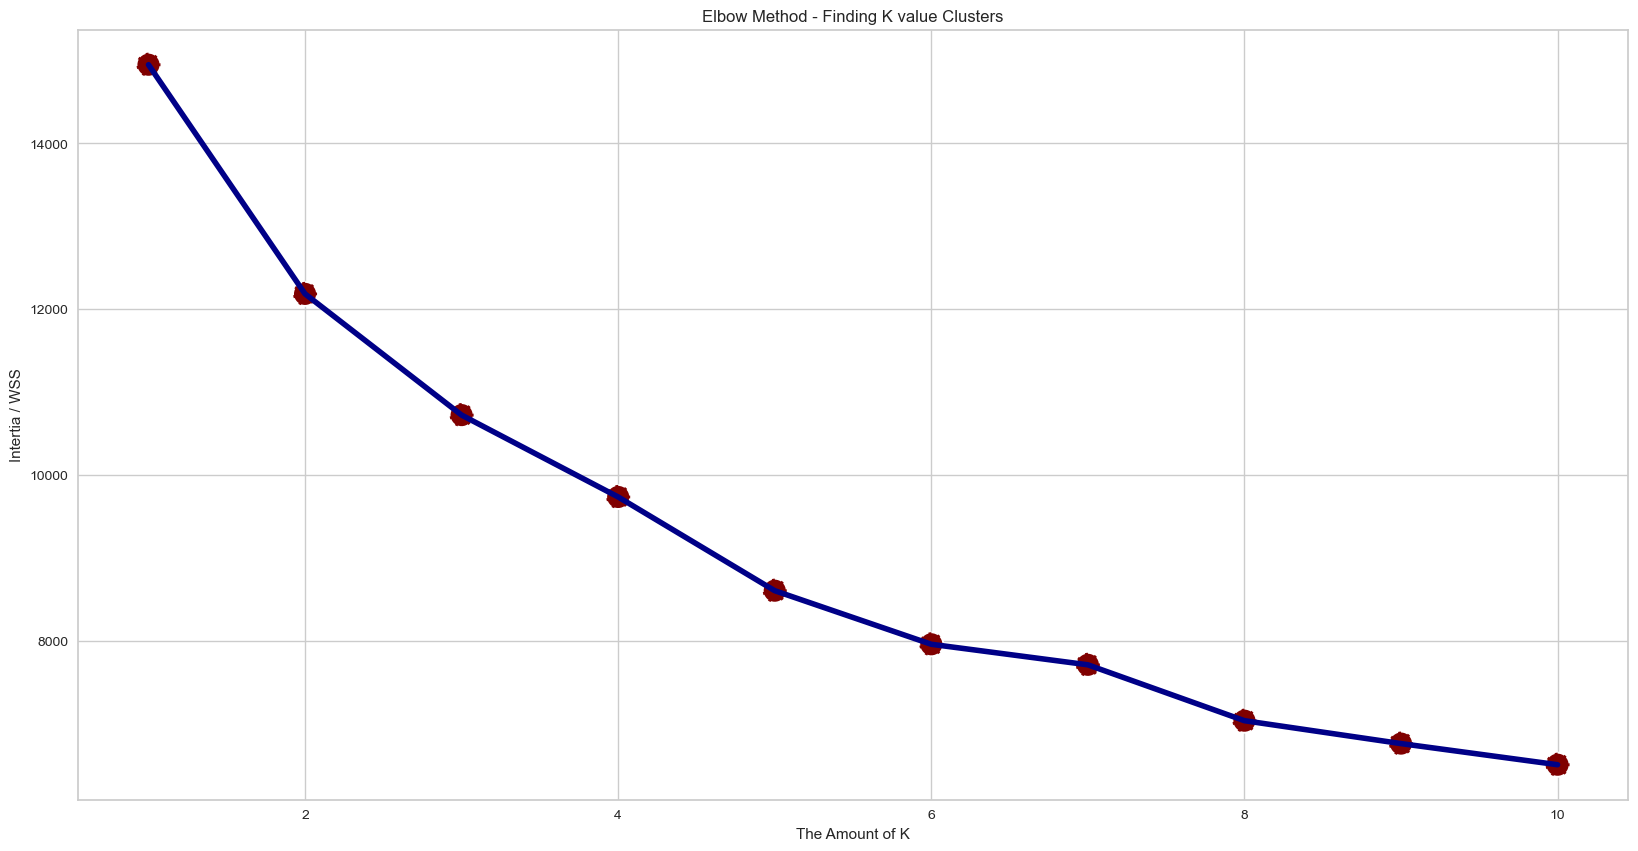

In [65]:
from sklearn.cluster import KMeans
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_scalling.values)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 10))

sns.lineplot(x=range(1, 11), y=inertia, color='#000087', linewidth = 4)
sns.scatterplot(x=range(1, 11), y=inertia, s=300, color='#800000',  linestyle='--')
plt.title('Elbow Method - Finding K value Clusters')
plt.xlabel('The Amount of K')
plt.ylabel('Intertia / WSS')

In [66]:
#Dari hasil diatas elbow nya dipilih pada angka 4,
# karena titik awal sebelum titik selanjutnya memiliki gap yang konstan atau
# titik setelah lekukan tajam sebelum mendatar
from sklearn.cluster import KMeans
kmeans_elbow = KMeans(n_clusters=4, random_state=0)
kmeans_elbow.fit(df_scalling.values)

KMeans(n_clusters=4, random_state=0)

In [67]:
#taruh hasil k-means elbow method ke df dengan nama kolom cluster_elbow
df['cluster_elbow'] = kmeans_elbow.labels_

In [68]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,cluster_elbow
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,3
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,3
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,3
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,2
4,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,5,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1354,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,3
1355,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,0
1356,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,0
1357,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,0


Text(0, 0.5, 'Quality')

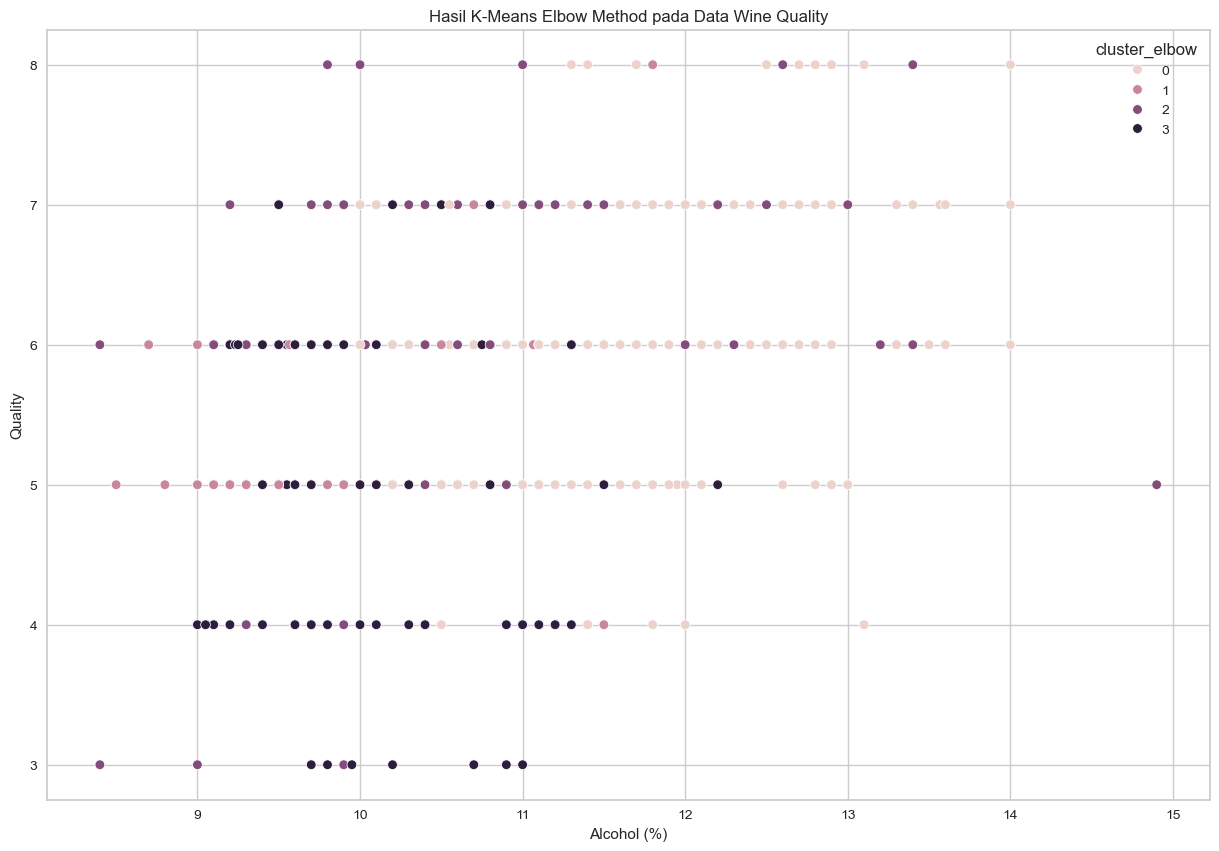

In [69]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='quality', hue='cluster_elbow')
plt.title('Hasil K-Means Elbow Method pada Data Wine Quality')
plt.xlabel('Alcohol (%)')
plt.ylabel('Quality')

### Bandingkan hasil dengan label quality

Text(0, 0.5, 'Quality')

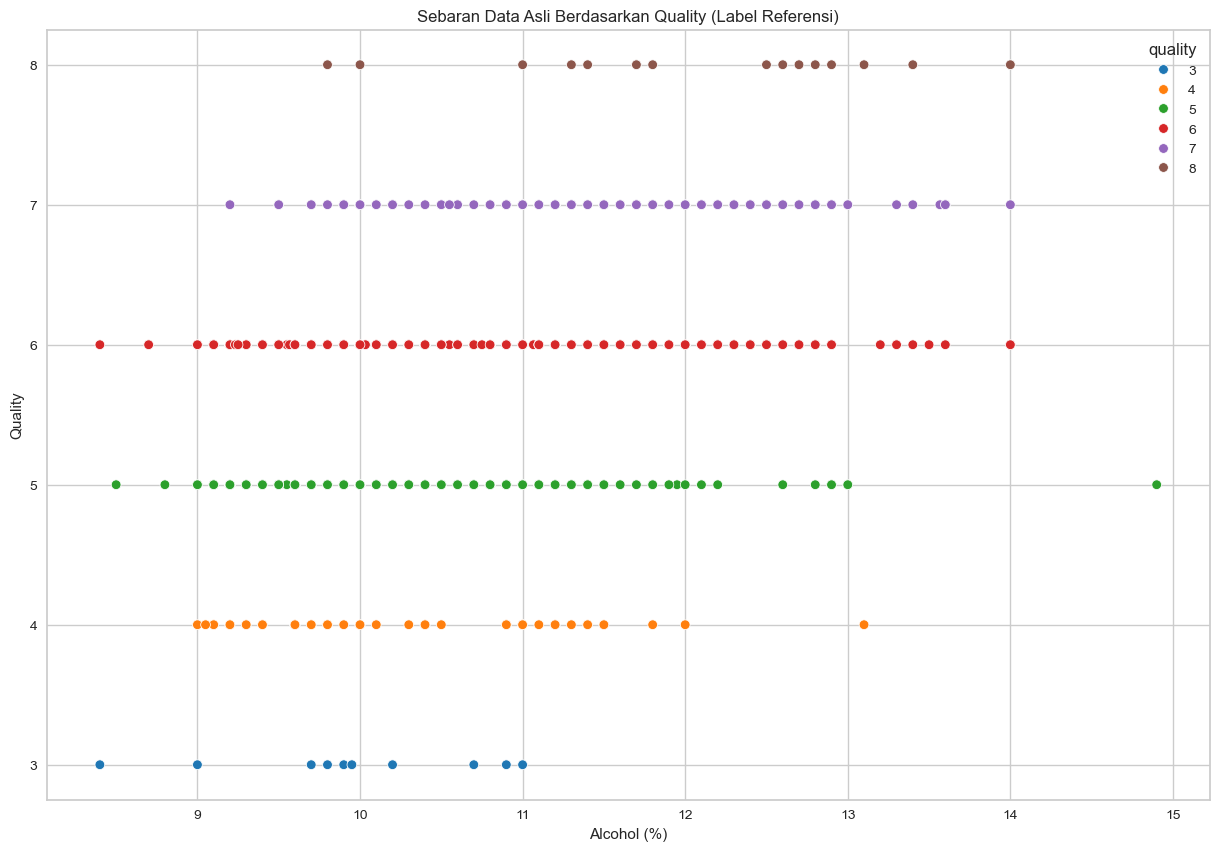

In [70]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='quality', hue='quality', palette='tab10')
plt.title('Sebaran Data Asli Berdasarkan Quality (Label Referensi)')
plt.xlabel('Alcohol (%)')
plt.ylabel('Quality')

### Hasil Analisis K-Means pada Dataset Wine Quality

Hasil clustering menggunakan K-Means menunjukkan pengelompokan data wine berdasarkan karakteristik fisika dan kimia. Dengan menggunakan semua fitur numerik (fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol) untuk clustering:

1. **Metode Elbow** mengidentifikasi jumlah cluster optimal dengan menganalisis perubahan inertia pada setiap penambahan cluster.
2. **Metode Via-Score** secara otomatis menentukan jumlah cluster terbaik berdasarkan distortion score.
3. **Visualisasi** menggunakan fitur 'alcohol' dan 'quality' untuk representasi 2D guna membandingkan hasil clustering dengan label quality yang ada.
4. Perbedaan antara cluster hasil K-Means dan label quality awal dapat disebabkan oleh:
   - Pengaruh fitur-fitur lain yang tidak terlihat pada plot 2D
   - Bobot berbeda dari setiap fitur setelah standardisasi
   - Struktur alami dalam data yang berbeda dengan kategori quality yang sudah ada
5. Hasil clustering valid jika menunjukkan pola yang konsisten dan meaningful pada ruang fitur yang digunakan.

### 2. Via Score Plot

In [71]:
%pip install yellowbrick

Note: you may need to restart the kernel to use updated packages.


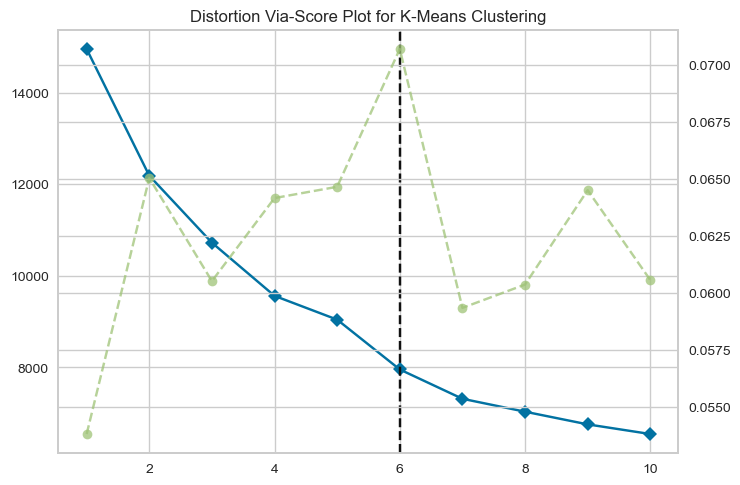

In [72]:
# Via Score Plot
from yellowbrick.cluster import KElbowVisualizer
k_means_via = KMeans()
# k is range of number of clusters.
visualizer = KElbowVisualizer(k_means_via, k=(1,11), timings= True)
visualizer.fit(df_scalling.values)        # Fit the data to the visualizer
plt.title('Distortion Via-Score Plot for K-Means Clustering')
plt.show()

In [73]:
# Dari hasil diatas K-nya dipilih pada angka 3,
# karena titik distorsinya bertemu pada nilai 3 di sumbu x
from sklearn.cluster import KMeans
kmeans_via = KMeans(n_clusters=3, random_state=0)
kmeans_via.fit(df_scalling.values)

KMeans(n_clusters=3, random_state=0)

In [74]:
#taruh hasil k-means via score method ke df dengan nama kolom cluster_via
df['cluster_via'] = kmeans_via.labels_

In [75]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,cluster_elbow,cluster_via
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,3,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,3,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,3,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,2,2
4,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,5,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1354,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,3,0
1355,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,0,0
1356,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,0,0
1357,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,0,0


## TO DO !
- Lakukan evaluasi pada k-means menggunakan via score secara visualisasi

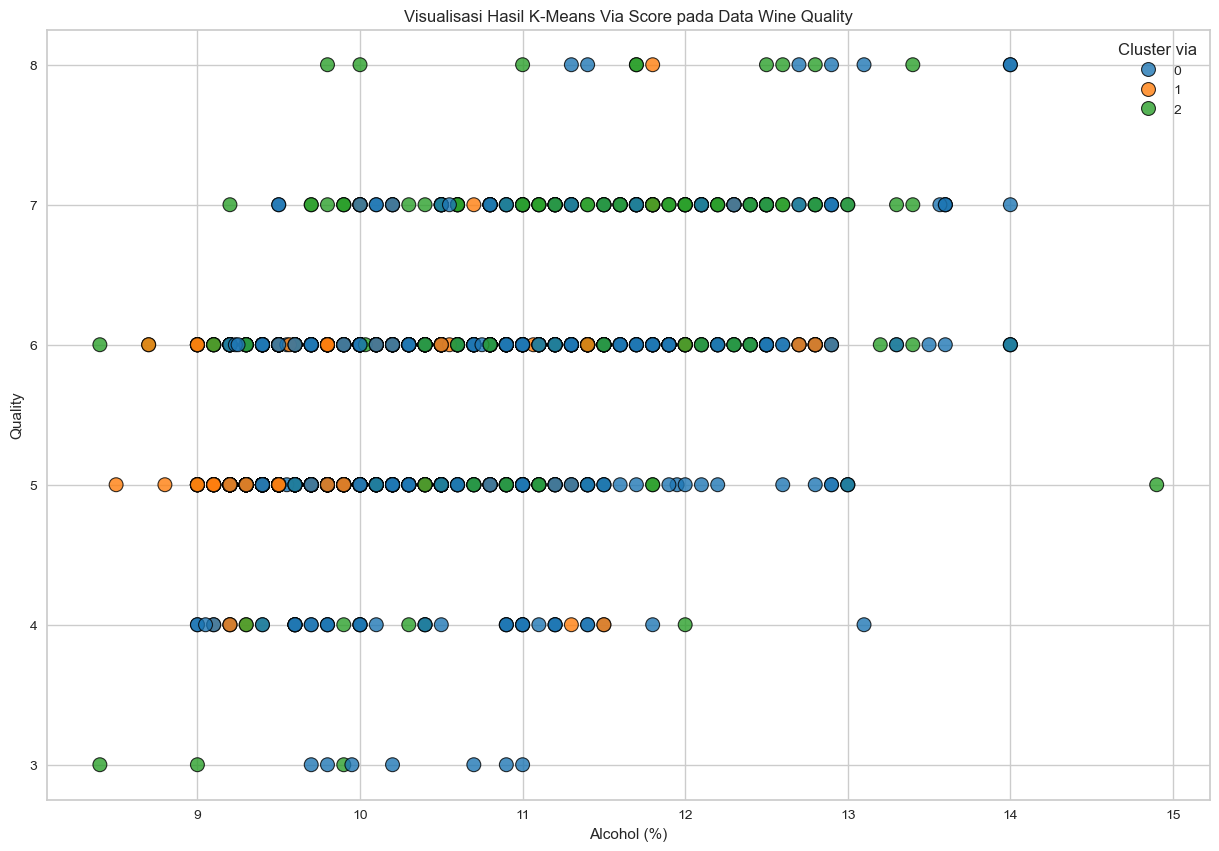

In [76]:
#Lakukan evaluasi setelah dilakukan K-Means
#Bandingkan hasil cluster dengan distribusi data asli
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='quality', hue='cluster_via', palette='tab10', s=100, edgecolor='black', alpha=0.8)
plt.title('Visualisasi Hasil K-Means Via Score pada Data Wine Quality')
plt.xlabel('Alcohol (%)')
plt.ylabel('Quality')
plt.legend(title='Cluster via')
plt.show()

### Bandingkan dengan label quality

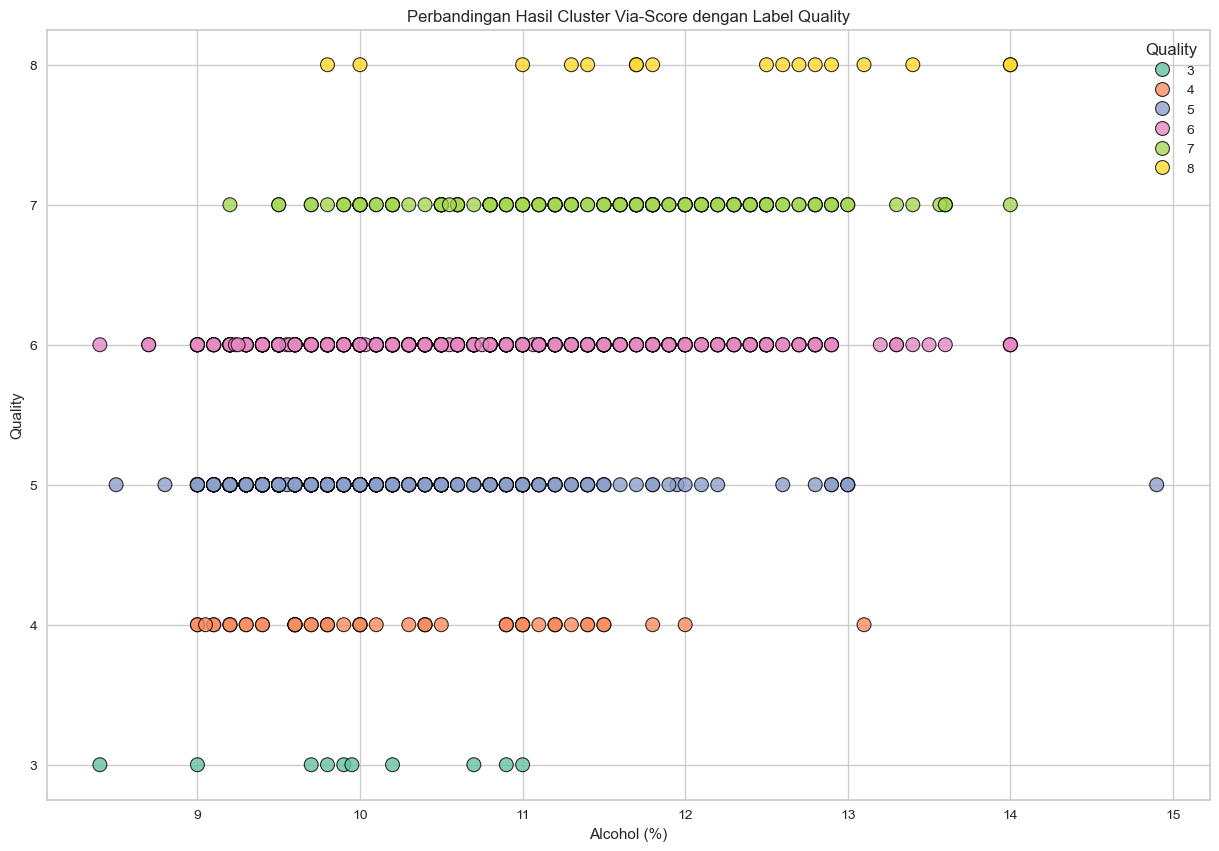

In [77]:
# Visualisasikan data asli berdasarkan label quality untuk perbandingan
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='quality', hue='quality', palette='Set2', s=100, edgecolor='black', alpha=0.8)
plt.title('Perbandingan Hasil Cluster Via-Score dengan Label Quality')
plt.xlabel('Alcohol (%)')
plt.ylabel('Quality')
plt.legend(title='Quality')
plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
1. Visualisasi dengan label quality menunjukkan distribusi kelompok asli berdasarkan `quality` yang dapat dibandingkan langsung dengan hasil cluster K-Means menggunakan semua 11 fitur numerik.
2. Metode Elbow menghasilkan **k=4 clusters**, sementara metode Via-Score menghasilkan **k=3 clusters**, menunjukkan bahwa struktur data wine quality memiliki kompleksitas moderat.
3. Perbandingan cluster K-Means dengan label quality membantu mengidentifikasi apakah clustering konsisten dengan rating kualitas yang sudah ada atau menunjukkan pola tersembunyi dalam data.
4. Dataset wine quality memiliki karakteristik multivariate dengan 11 fitur yang saling berinteraksi (seperti alcohol, pH, sulphates, acidity). K-Means menggunakan semua fitur ini untuk membentuk cluster yang optimal.
5. Perbedaan antara cluster hasil K-Means dan label quality awal kemungkinan disebabkan oleh:
   - Fitur-fitur kimia dan fisik lainnya memiliki pengaruh signifikan yang tidak terlihat pada plot 2D (alcohol vs quality)
   - Beberapa sampel wine dengan quality rating yang sama dapat memiliki profil kimia yang berbeda, sehingga dikelompokkan ke cluster berbeda
   - Label quality adalah rating subjektif, sementara clustering K-Means mencari pengelompokan berdasarkan jarak Euclidean dalam ruang fitur berdimensi tinggi
6. Cluster yang dihasilkan valid jika menunjukkan pola yang konsisten dan meaningful dalam ruang fitur multivariate, bahkan jika berbeda dari rating quality yang sudah ada.
7. Visualisasi scatter plot alcohol vs quality membantu interpretasi visual, namun keputusan clustering didasarkan pada semua 11 fitur yang telah distandarisasi menggunakan StandardScaler.

### Thank you :)